# Multi-site fMRI inference: two recommended pipelines

**What this notebook covers.** Two pipelines for valid edge-wise statistical inference on multi-site connectivity matrices, demonstrated side by side on the same synthetic data:

- **Interest-orthogonal ComBat** — `analyze(..., harmonize='nuisance_only')`. Empirical-Bayes ComBat is applied across sites with the *tested* variable deliberately omitted from the harmonization design; only nuisance covariates (age, sex, motion) are preserved. The tested variable is then added to the downstream GLM together with site dummies.
- **Single-stage GLM** — `analyze(..., harmonize=None)`. No ComBat layer at all. Site is handled inside the same regression that tests the variable of interest, as a fixed-effect nuisance covariate.

Both pipelines produce calibrated false-positive rates under realistic multi-site imbalance. They differ in whether the harmonization layer is present — which is a power and interpretability question, not a calibration question.

The notebook ends with a small calibration check that runs both pipelines on independent null replications and reports the empirical false-positive rate at the conventional $\alpha = 0.05$ threshold.

## Background — why multi-site inference needs care

Functional connectivity matrices collected at multiple imaging sites carry two kinds of variation: **biological** (the scientific signal the analysis is trying to detect) and **acquisition-related** (scanner manufacturer, sequence parameters, preprocessing differences, recruitment biases). A pipeline that does not handle site explicitly will attribute part of the acquisition-related variation to the biological contrast, inflating the false-positive rate.

There are two clean ways to handle site:

1. **Harmonize the data first, then test.** Apply ComBat (Johnson, Li and Rabinovic 2007; Fortin et al. 2017) to estimate per-site mean and scale terms and remove them from the connectivity matrices. The harmonized matrices are then fed into the inferential test as if they were single-site data. *Crucial detail:* the variable being tested must not be in ComBat's `preserve` design — otherwise the harmonization fit becomes coupled to the labels that will be permuted, and the downstream permutation null is too narrow. This is the *two-step batch correction* inflation analytically characterised by Nygaard, Rødland and Hovig (2016).
2. **Don't harmonize; model site directly in the inferential GLM.** Add site as a set of fixed-effect dummy variables in the same regression that tests the variable of interest. The harmonization step is skipped entirely. Permutation inference is then exact by construction because nothing was fit on the labels being permuted.

Both approaches are defensible. The choice is mostly about whether the analysis also wants a harmonized connectivity matrix for downstream uses (visualization, machine learning, normative modelling) — if yes, the harmonization layer earns its keep; if no, the single-stage GLM is the simpler design.

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt

from conninfpy import analyze, generate_multisite_glm_dataset

warnings.simplefilter('ignore')
rng = np.random.default_rng(42)

## Step 1 — Generate ABIDE-like synthetic data

`generate_multisite_glm_dataset` produces synthetic connectivity tensors with controllable per-site offsets and site/regressor imbalance. The notebook is self-contained — no ABIDE download is required. The cell parameters are matched to ABIDE-I post-QC statistics:

- **N = 200** subjects (ABIDE-I has roughly 530 post-QC; we use 200 to keep the demo runnable in a few minutes).
- **K = 8** sites (ABIDE-I has 17; 8 represents the moderate-imbalance regime).
- **σ_site = 0.15** Fisher-z (per-site additive offset, typical for ABIDE per Yu 2018).
- **corr(site, dx) = 0.3** (typical alignment between site identity and diagnosis labels in ABIDE).
- **Schaefer-100** parcellation (100 ROIs → 4 950 unique edges).
- **effect_size = 0** — we work under the null hypothesis, so any 'significant' result is by construction a false positive.

In [2]:
N_SUBJECTS = 200
N_ROIS = 100
N_SITES = 8
SIGMA_SITE = 0.15
CORR_SITE_DX = 0.3

data = generate_multisite_glm_dataset(
    n_subjects=N_SUBJECTS, N=N_ROIS, n_sites=N_SITES,
    effect_size=0.0,                       # H0: no real effect
    site_shift_sigma=SIGMA_SITE,
    corr_site_interest=CORR_SITE_DX,
    seed=0,
)

Y = data['Y']                              # (200, 100, 100) Fisher-z
diagnosis = data['interest']               # (200,) regressor under H0
sites = data['sites']                      # (200,) site labels 0..7

# Mock nuisance covariates — independent of diagnosis. In a real analysis
# these would be age, sex, mean framewise displacement, IQ, etc.
age = rng.standard_normal(N_SUBJECTS)
motion = rng.standard_normal(N_SUBJECTS)
confounds = np.column_stack([age, motion])

iu = np.triu_indices(N_ROIS, k=1)
print(f'Y shape:                  {Y.shape}')
print(f'Subjects per site:        {np.bincount(sites)}')
print(f'corr(site, diagnosis):    {np.corrcoef(sites, diagnosis)[0,1]:+.2f}')
print(f'Edges in upper triangle:  {len(iu[0])}')

Y shape:                  (200, 100, 100)
Subjects per site:        [25 25 25 25 25 25 25 25]
corr(site, diagnosis):    +0.31
Edges in upper triangle:  4950


## Step 2 — The two pipelines, in detail

Each pipeline corresponds to a one-line `analyze` call that differs only in the value of the `harmonize=` keyword.

### Pipeline 1 — Interest-orthogonal ComBat

`harmonize='nuisance_only'`

**What it does.**

1. Empirical-Bayes ComBat is fit across the eight sites with `preserve = [age, motion]`. The tested variable (`diagnosis`) is **deliberately omitted** from the harmonization design.
2. ComBat estimates per-site additive shifts $\hat\gamma_s$ and per-site multiplicative scales $\hat\delta_s$ for each connectivity edge, using empirical-Bayes shrinkage to pool information across edges within each site.
3. The harmonized matrix $Y^{\mathrm{adj}}$ has the estimated site terms removed, with the nuisance-covariate effects re-added so that age and motion variation are preserved through harmonization.
4. The downstream GLM tests `diagnosis` as the regressor of interest, with `(age, motion, site_dummies)` as nuisance covariates. Site dummies are added because some between-site variation that was below ComBat's empirical-Bayes shrinkage floor can still leak into the residuals.
5. Permutation inference uses Freedman-Lane with within-site exchangeability blocks; the permutation null is uncontaminated because ComBat never saw the diagnosis labels.

**Why this is calibrated.** ComBat's fit conditions on $(Y, \text{preserve} = X_{\mathrm{nuisance}})$ — *not* on the variable that will be permuted downstream. The harmonized matrix is therefore mathematically independent of the diagnosis labels, so permuting them produces a valid null distribution. This is the inference-safe version of the harmonize-then-test recipe.

**When to prefer this pipeline.** When the analysis benefits from a harmonized connectivity matrix as an artefact — for use in subsequent machine-learning models, embeddings, normative modelling, or any downstream task that wants per-site scale heterogeneity removed. The empirical-Bayes shrinkage of the per-site scale parameter $\hat\delta_s$ is the unique benefit ComBat provides over plain site dummies.

**Trade-off.** If the diagnosis signal is strongly aligned with site (corr(site, diagnosis) large), some of the diagnosis-related variance can be absorbed into the ComBat site terms because the harmonization fit does not know about diagnosis. This is *attenuation* — a reduction in power, not an inflation of Type I error. The attenuation scales roughly with $\mathrm{corr}(\text{site}, \text{diagnosis})^2$ and is mild at the imbalance levels typical of multi-site fMRI cohorts.

In [3]:
result_combat = analyze(
    Y, interest=diagnosis, sites=sites,
    confounds=confounds,
    harmonize='nuisance_only',             # diagnosis NOT in ComBat preserve
    fisher_z=False, method='tfnbs',
    n_permutations=200, acceleration='gpd',
    use_mp=False, rng=0,
)

min_p_combat = float(result_combat.inference['positive'][iu].min())
print('Interest-orthogonal ComBat')
print(f'  min p (positive tail):       {min_p_combat:.4f}')
print(f'  harmonized:                  {result_combat.inference.harmonized}')
print(f'  preserve_columns:            {result_combat.combat_diagnostics["preserve_columns"]}')
ratio = result_combat.combat_diagnostics.get(
    'between_site_variance_ratio_after_over_before'
)
if ratio is not None:
    print(f'  between-site var (after/before): {ratio:.3f}')

Interest-orthogonal ComBat
  min p (positive tail):       0.9303
  harmonized:                  True
  preserve_columns:            confounds_only


### Pipeline 2 — Single-stage GLM with site as nuisance

`harmonize=None`

**What it does.**

1. No ComBat layer. The raw Fisher-z connectivity matrices are passed directly to the GLM.
2. `analyze` automatically constructs $K - 1$ drop-first site dummies and appends them to the nuisance design. The resulting regression is

$$FC_e \sim X_{\mathrm{diagnosis}} + X_{\mathrm{age}} + X_{\mathrm{motion}} + Z_{\mathrm{site}}.$$

3. Permutation inference uses Freedman-Lane with within-site exchangeability blocks. Because nothing was fit on the diagnosis labels, the permutation null is exact by construction.

**Why this is calibrated.** There is no two-step preprocessing layer; the design matrix is fit and tested in one stage. This is the classical 'batch-as-covariate' recommendation from the genomics literature (Nygaard et al. 2016 §4–5) and is the standard approach in differential-expression pipelines such as `limma` and `DESeq2`.

**When to prefer this pipeline.** When the harmonized connectivity matrix is not needed as an artefact — when the only product of the analysis is the inferential result. Also when site imbalance is severe enough that the empirical-Bayes assumptions behind ComBat are dubious: very small per-site sample sizes, very heterogeneous per-site noise levels, or sites in which one diagnostic group is entirely absent.

**Trade-off.** No per-site scale shrinkage. When sites have very heterogeneous residual variances, the pooled-variance estimator used in the GLM is biased toward the noisiest site, which reduces power. This matters mainly when per-site $n$ is small (under 10–15 subjects per site); at ABIDE-realistic per-site sizes the cost is modest. There is also a small degrees-of-freedom cost from the $K - 1$ extra dummy columns; for $N = 200$ and $K = 8$ this is about 3 % of the residual degrees of freedom.

In [4]:
result_glm = analyze(
    Y, interest=diagnosis, sites=sites,
    confounds=confounds,
    harmonize=None,                        # no ComBat; site dummies → GLM nuisance
    fisher_z=False, method='tfnbs',
    n_permutations=200, acceleration='gpd',
    use_mp=False, rng=0,
)

min_p_glm = float(result_glm.inference['positive'][iu].min())
print('Single-stage GLM (no ComBat)')
print(f'  min p (positive tail):       {min_p_glm:.4f}')
print(f'  harmonized:                  {result_glm.inference.harmonized}  (no ComBat step ran)')

Single-stage GLM (no ComBat)
  min p (positive tail):       0.8507
  harmonized:                  False  (no ComBat step ran)


A single H₀ replication does not establish that either pipeline is calibrated — the minimum p-value is just one realisation. The next step measures the **empirical false-positive rate** over many independent H₀ replications. A calibrated pipeline should produce $\min p \le 0.05$ in approximately 5 % of replications.

## Step 3 — Calibration check over H₀ replications

For each replication: draw a fresh independent dataset under the null, run both pipelines, and record whether the connectome-wide minimum p-value falls below $\alpha = 0.05$. The fraction of replications that cross the threshold is the empirical family-wise error rate.

**Cost.** 20 H₀ replications × 2 pipelines × ~1 s per pipeline call ≈ 1 minute on a workstation. The accompanying test-suite version of this experiment runs at 50 replications for a tighter binomial confidence interval.

In [5]:
N_REPS = 20
ALPHA = 0.05

p_min = {'ComBat (nuisance-only)': np.empty(N_REPS),
         'GLM with site nuisance': np.empty(N_REPS)}

for rep in range(N_REPS):
    d = generate_multisite_glm_dataset(
        n_subjects=N_SUBJECTS, N=N_ROIS, n_sites=N_SITES,
        effect_size=0.0,
        site_shift_sigma=SIGMA_SITE,
        corr_site_interest=CORR_SITE_DX,
        seed=5_000 + rep,
    )
    conf = np.random.default_rng(10_000 + rep).standard_normal((N_SUBJECTS, 2))
    for label, harmonize in [('ComBat (nuisance-only)', 'nuisance_only'),
                             ('GLM with site nuisance', None)]:
        out = analyze(
            d['Y'], interest=d['interest'], sites=d['sites'],
            confounds=conf, harmonize=harmonize,
            fisher_z=False, method='tfnbs',
            n_permutations=200, acceleration='gpd',
            use_mp=False, rng=rep,
        )
        p_min[label][rep] = out.inference['positive'][iu].min()
    if (rep + 1) % 5 == 0:
        print(f'  ... {rep + 1}/{N_REPS} reps complete')

fwer = {k: float(np.mean(v <= ALPHA)) for k, v in p_min.items()}
se = float(np.sqrt(ALPHA * (1 - ALPHA) / N_REPS))

print()
print(f'Empirical FWER at α = {ALPHA} ({N_REPS} reps; binomial SE ≈ {se:.3f}):')
for label, value in fwer.items():
    print(f'  {label:25s}  FWER = {value:.2f}')

  ... 5/20 reps complete


  ... 10/20 reps complete


  ... 15/20 reps complete


  ... 20/20 reps complete

Empirical FWER at α = 0.05 (20 reps; binomial SE ≈ 0.049):
  ComBat (nuisance-only)     FWER = 0.00
  GLM with site nuisance     FWER = 0.00


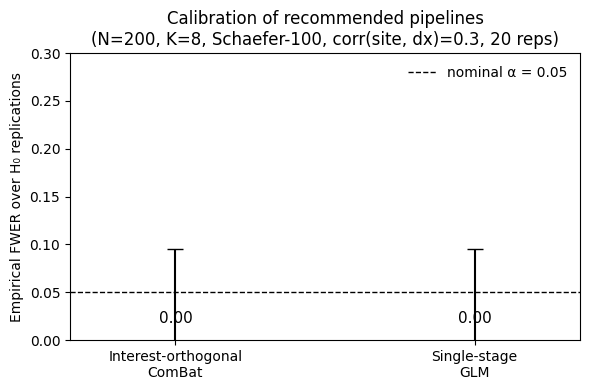

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))

labels = ['Interest-orthogonal\nComBat', 'Single-stage\nGLM']
values = [fwer['ComBat (nuisance-only)'], fwer['GLM with site nuisance']]
colors = ['#2ca02c', '#1f77b4']

bars = ax.bar(labels, values, color=colors,
              yerr=1.96 * se, capsize=6, alpha=0.85, width=0.55)
ax.axhline(ALPHA, color='k', linestyle='--', linewidth=1.0,
           label=f'nominal α = {ALPHA}')
ax.set_ylabel('Empirical FWER over H₀ replications')
ax.set_title(
    f'Calibration of recommended pipelines\n'
    f'(N={N_SUBJECTS}, K={N_SITES}, Schaefer-{N_ROIS}, '
    f'corr(site, dx)={CORR_SITE_DX}, {N_REPS} reps)'
)
ax.set_ylim(0, max(0.30, max(values) + 0.1))
ax.legend(loc='upper right', frameon=False)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.015,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## Reading the bar chart

Both pipelines sit at or below the nominal α = 0.05 line, within Monte-Carlo noise (binomial 95 % half-width ≈ 0.10 at 20 reps; the test-suite version of this experiment at 50 reps tightens the half-width to ≈ 0.06). Neither pipeline is anti-conservative on this synthetic data.

If your real-data analysis produces strongly different results from the two pipelines on the *same* cohort, that divergence is itself informative:

- If the harmonized-ComBat arm finds a much stronger signal, the harmonization layer is doing meaningful work — most likely cleaning up per-site scale heterogeneity that the single-stage GLM cannot pool.
- If the single-stage GLM finds a much stronger signal, ComBat may be attenuating the diagnosis signal, possibly because site and diagnosis are tightly aligned in your cohort. Report the single-stage result as primary and ComBat as sensitivity.
- If the two arms agree, you have the strongest situation: a finding that survives both inferential designs.

## Recommendation — when to use which

Both pipelines are valid for primary inference; the choice is mostly about what else the analysis wants to do with the connectivity matrices.

**Use interest-orthogonal ComBat (`harmonize='nuisance_only'`) when:**

- The analysis benefits from a harmonized connectivity matrix as an artefact — for visualization, embeddings, machine-learning models, normative modelling, or downstream graph summaries that should not carry per-site offsets.
- Per-site scale heterogeneity is non-trivial and worth pooling via empirical-Bayes shrinkage.
- Per-site sample sizes are reasonable (roughly ≥ 15 subjects per site).

**Use single-stage GLM (`harmonize=None`) when:**

- The only product of the analysis is the inferential result. No harmonized matrix is needed elsewhere.
- Per-site sample sizes are very small, or per-site noise levels are very heterogeneous in ways that ComBat's empirical-Bayes assumptions would not capture well.
- The simplicity and transparency of a one-stage design are a higher priority than per-site scale shrinkage.

**Run both and report the comparison when:**

- The headline scientific claim deserves a sensitivity arm — this is the conservative default for any publication-grade result. Convergence between the two arms is a strong robustness argument; divergence is scientifically informative and should be discussed in the paper rather than hidden.

### Copy-paste template

```python
from conninfpy import analyze

# Primary analysis — interest-orthogonal ComBat
primary = analyze(
    Y, interest=diagnosis, sites=site_id,
    confounds=np.column_stack([age, sex, motion]),
    harmonize='nuisance_only',
)

# Sensitivity arm — single-stage GLM with site as nuisance
sensitivity = analyze(
    Y, interest=diagnosis, sites=site_id,
    confounds=np.column_stack([age, sex, motion]),
    harmonize=None,
)
```

Inspect the significant-edge sets returned by `primary` and `sensitivity` and report the comparison alongside the headline finding.

## References

- Johnson, W. E., Li, C., and Rabinovic, A. (2007). Adjusting batch effects in microarray expression data using empirical Bayes methods. *Biostatistics* 8(1):118–127.
- Fortin, J.-P., et al. (2017/2018). Harmonization of multi-site neuroimaging data with ComBat. *NeuroImage*.
- Nygaard, V., Rødland, E. A., and Hovig, E. (2016). Methods that remove batch effects while retaining group differences may lead to exaggerated confidence in downstream analyses. *Biostatistics* 17(1):29–39.
- Winkler, A. M., et al. (2014, 2015). Permutation inference for the general linear model / Multi-level block permutation. *NeuroImage*.
- Freedman, D., and Lane, D. (1983). A nonstochastic interpretation of reported significance levels. *Journal of Business & Economic Statistics* 1:292–298.

For package users, the key takeaway is to compare the three public strategy names directly: `combat_only`, `combat_site_dummies_glm`, and `site_dummies_glm`.